In [9]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix

In [14]:
# Additional imports for preprocessing and feature extraction
import cv2
from PIL import Image
from skimage.feature import local_binary_pattern

In [15]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [16]:
# ============================================
# Custom Preprocessing and Feature Extraction
# ============================================

class CustomPreprocessing:
    """
    Custom transform that:
      - Converts the input PIL image to a NumPy array.
      - Converts it to HSV and applies histogram equalization on the Value channel.
      - Converts back to RGB.
      - Performs segmentation & edge detection by resizing to 64x64 and applying Sobel.
      - Extracts features:
          * Color: Mean RGB values.
          * Texture: LBP histogram.
          * Shape: Hu Moments.
      - Applies a base transform (e.g. resize, crop, normalize) to prepare the image for the CNN.
    Returns:
      - image_tensor: Tensor ready for CNN input.
      - features: A NumPy array with the extracted features.
    """
    def __init__(self, base_transform=None):
        self.base_transform = base_transform

    def __call__(self, img):
        # Convert PIL image to NumPy array (RGB)
        img_np = np.array(img)
        # If the image is grayscale, convert it to RGB
        if img_np.ndim == 2:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        
        # ----- Enhancement: Convert to HSV and equalize histogram on V channel -----
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        hsv[:, :, 2] = cv2.equalizeHist(hsv[:, :, 2])
        img_enhanced = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        
        # ----- Segmentation & Edge Detection -----
        # Resize to 64x64 for segmentation and edge detection
        resized = cv2.resize(img_enhanced, (64, 64))
        # Convert to grayscale for edge detection and LBP
        gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
        # Compute Sobel gradients
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = np.sqrt(sobelx**2 + sobely**2)
        if np.max(sobel) != 0:
            sobel = np.uint8(255 * sobel / np.max(sobel))
        else:
            sobel = np.uint8(sobel)
        
        # ----- Feature Extraction -----
        # Color Features: Mean RGB values from the enhanced image
        mean_rgb = img_enhanced.mean(axis=(0, 1))  # (3,)
        
        # Texture Features: Local Binary Patterns (LBP)
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
        (hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, n_points + 3),
                                 range=(0, n_points + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)  # Normalize histogram
        
        # Shape Features: Hu Moments computed from the Sobel edge image
        moments = cv2.moments(sobel)
        hu_moments = cv2.HuMoments(moments).flatten()  # (7,)
        
        # Combine all features into a single feature vector
        features = np.concatenate([mean_rgb, hist, hu_moments])  # Total length = 3 + (n_points+2) + 7
        
        # ----- Prepare Image for CNN -----
        if self.base_transform is not None:
            # Convert the enhanced image back to a PIL image for further processing
            img_enhanced_pil = Image.fromarray(img_enhanced)
            image_tensor = self.base_transform(img_enhanced_pil)
        else:
            image_tensor = torch.from_numpy(img_enhanced.transpose(2, 0, 1)).float() / 255.0

        return image_tensor, features

In [17]:
# ============================================
# Custom Dataset Class
# ============================================

class CustomImageFolder(datasets.ImageFolder):
    """
    This custom dataset is similar to ImageFolder but applies our custom transform.
    Each __getitem__ returns a tuple: ((image_tensor, features), label)
    """
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            image_tensor, features = self.transform(sample)
        else:
            image_tensor = sample
            features = None
        if self.target_transform is not None:
            target = self.target_transform(target)
        return (image_tensor, features), target

In [18]:
# ============================================
# Data Preparation
# ============================================

# Define data directories (change these to your dataset paths)
train_dir = r"D:\pr\HAIR_LOSS_DL\Dataset\train" 
val_dir   = r"D:\pr\HAIR_LOSS_DL\Dataset\val"      

In [19]:
# Define base transforms (for CNN input) for training and validation
base_transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

base_transform_val = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [20]:
# Wrap the base transforms with our custom preprocessing
train_transform = CustomPreprocessing(base_transform=base_transform_train)
val_transform   = CustomPreprocessing(base_transform=base_transform_val)

In [21]:
# Create custom datasets and dataloaders
image_datasets = {
    "train": CustomImageFolder(train_dir, transform=train_transform),
    "val": CustomImageFolder(val_dir, transform=val_transform)
}

In [22]:
# For debugging, you can set num_workers=0. Once the issue is resolved, you may set it back to a higher number.
batch_size = 32
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x=="train"), num_workers=0)
    for x in ["train", "val"]
}

In [23]:

# For visualization and reports, get class names and dataset sizes.
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "val"]}
class_names = image_datasets["train"].classes
num_classes = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [24]:
# ============================================
# 2. Training and Evaluation Functions
# ============================================

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # To store loss and accuracy history
    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        # Each epoch has a training and validation phase
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluation mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            # Note: each batch returns ((image_tensor, features), labels)
            for (inputs, features), labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                # (Optional) features are available here as a NumPy array for each image if needed.

                optimizer.zero_grad()

                # Forward pass (track history only in training)
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # deep copy the model if validation accuracy improved
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step()

    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for (inputs, features), labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(12, 5))
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

In [25]:
# ============================================
# 3. Model Builders
# ============================================

def get_resnet50():
    model = models.resnet50(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

def get_densenet121():
    model = models.densenet121(pretrained=True)
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes)
    return model

def get_efficientnet_b0():
    model = models.efficientnet_b0(pretrained=True)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    return model

# Dictionary of model builders
model_builders = {
    "ResNet50": get_resnet50,
    "DenseNet121": get_densenet121,
    "EfficientNetB0": get_efficientnet_b0,
}


Training ResNet50...


C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\ajayv/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%



Epoch 1/2
----------
Train Loss: 0.4894 Acc: 0.8131
Val Loss: 6.9950 Acc: 0.5439

Epoch 2/2
----------
Train Loss: 0.3834 Acc: 0.8486
Val Loss: 1.8437 Acc: 0.5607

Training complete in 5m 45s
Best val Acc: 0.5607

Classification Report for ResNet50:
                 precision    recall  f1-score   support

Alopecia Areata       1.00      0.19      0.32       291
   Normal hairs       0.51      1.00      0.67       244

       accuracy                           0.56       535
      macro avg       0.75      0.60      0.50       535
   weighted avg       0.78      0.56      0.48       535



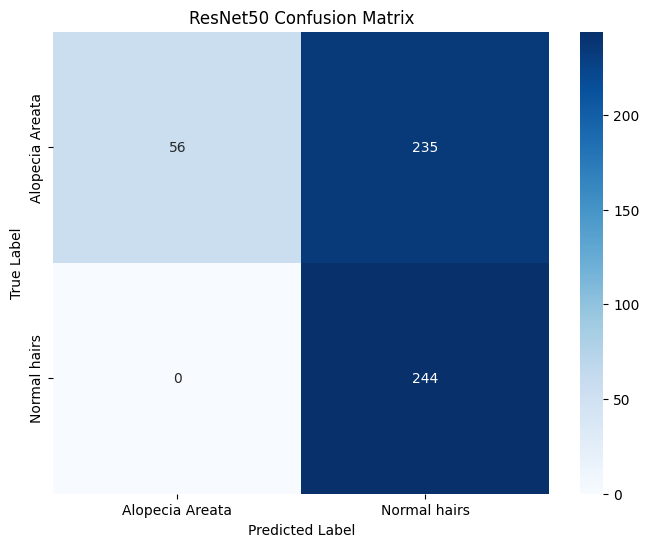

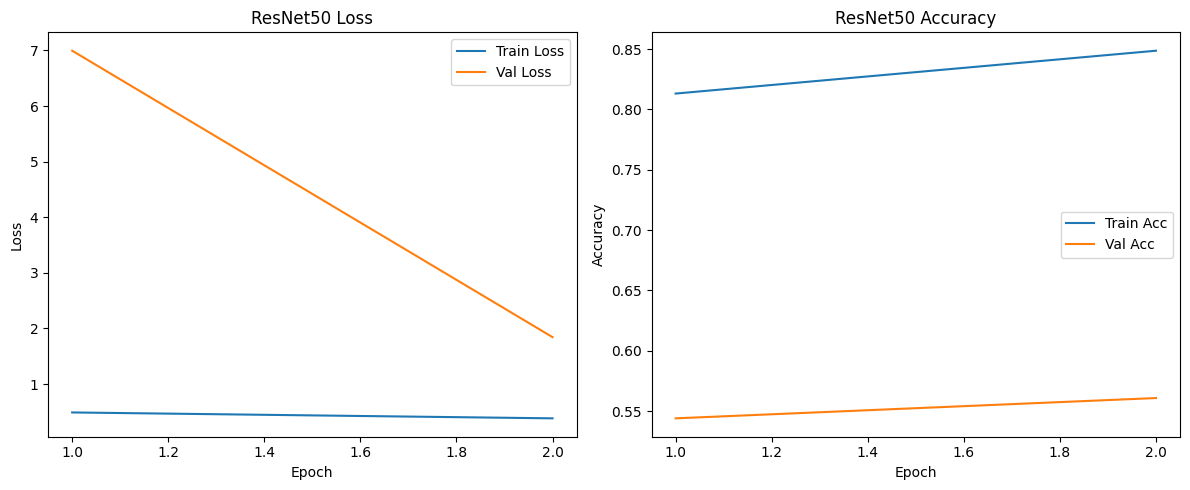


Training DenseNet121...


C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\ajayv/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100.0%



Epoch 1/2
----------
Train Loss: 0.3418 Acc: 0.8561
Val Loss: 2.4418 Acc: 0.6636

Epoch 2/2
----------
Train Loss: 0.2719 Acc: 0.9028
Val Loss: 0.8207 Acc: 0.8187

Training complete in 5m 27s
Best val Acc: 0.8187

Classification Report for DenseNet121:
                 precision    recall  f1-score   support

Alopecia Areata       0.79      0.90      0.84       291
   Normal hairs       0.86      0.72      0.78       244

       accuracy                           0.82       535
      macro avg       0.83      0.81      0.81       535
   weighted avg       0.82      0.82      0.82       535



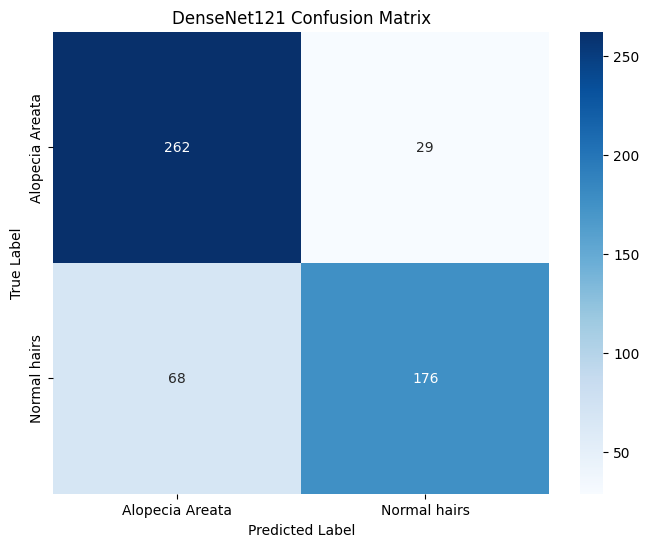

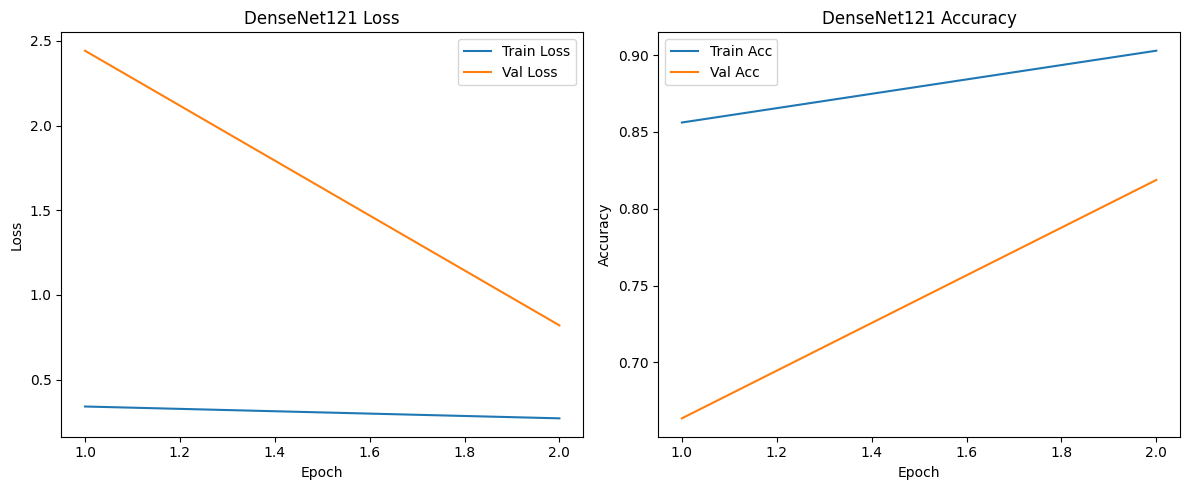


Training EfficientNetB0...


C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ajayv\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ajayv/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100.0%



Epoch 1/2
----------
Train Loss: 0.2738 Acc: 0.8579
Val Loss: 0.0711 Acc: 0.9869

Epoch 2/2
----------
Train Loss: 0.1047 Acc: 0.9551
Val Loss: 0.0490 Acc: 0.9776

Training complete in 3m 4s
Best val Acc: 0.9869

Classification Report for EfficientNetB0:
                 precision    recall  f1-score   support

Alopecia Areata       1.00      0.98      0.99       291
   Normal hairs       0.97      1.00      0.99       244

       accuracy                           0.99       535
      macro avg       0.99      0.99      0.99       535
   weighted avg       0.99      0.99      0.99       535



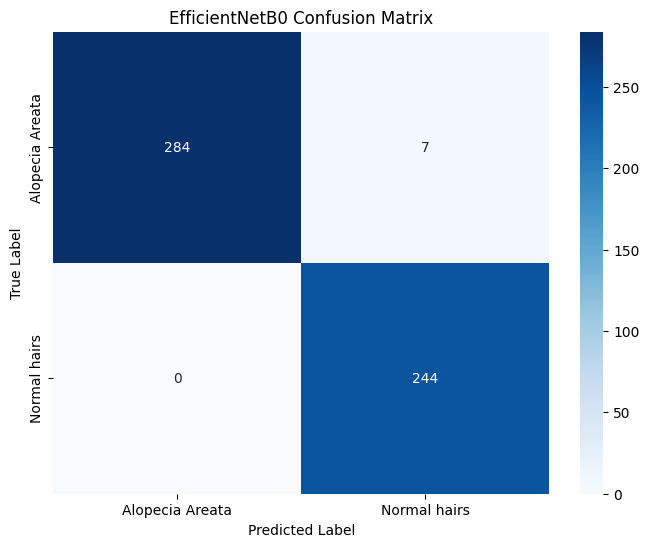

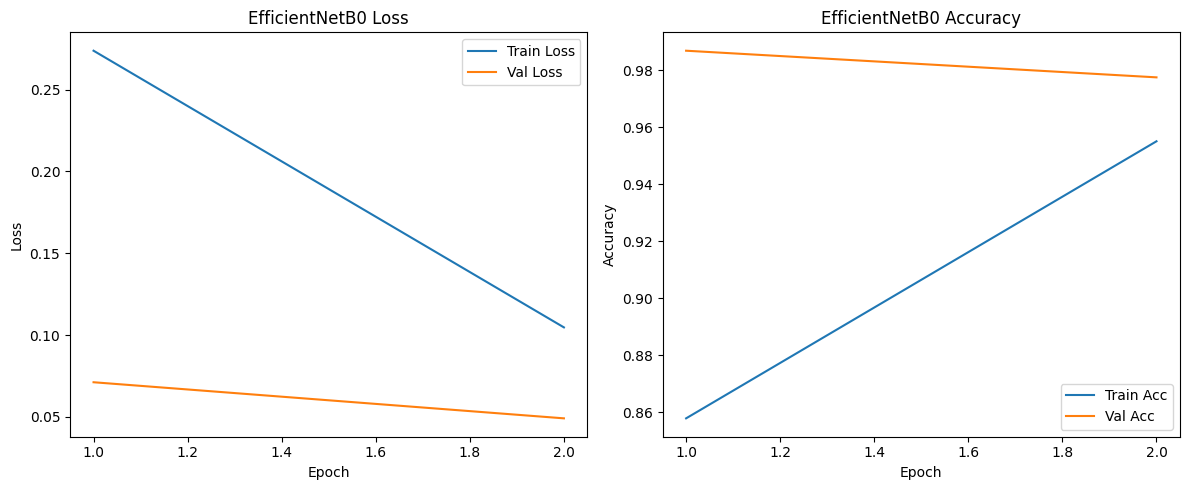

In [26]:
# ============================================
# 4. Main: Training, Evaluation, and Saving Best Model
# ============================================

# Hyperparameters
num_epochs = 2  # Adjust as needed (use more epochs for better performance)
learning_rate = 0.001

# Dictionaries to store results and best overall model info
results_dict = {}
overall_best_acc = 0.0
overall_best_model_name = None
overall_best_state_dict = None

# Loop through each model
for model_name, build_model in model_builders.items():
    print("\n" + "=" * 40)
    print(f"Training {model_name}...")
    print("=" * 40)
    
    # Build model and move to device
    model = build_model().to(device)
    
    # Define loss, optimizer, and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    # Train the model
    model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)
    
    # Record best validation accuracy for this model
    best_val_acc = max(history["val_acc"])
    results_dict[model_name] = best_val_acc
    
    # Update overall best model if applicable
    if best_val_acc > overall_best_acc:
        overall_best_acc = best_val_acc
        overall_best_model_name = model_name
        overall_best_state_dict = copy.deepcopy(model.state_dict())
    
    # Evaluate on validation set
    y_true, y_pred = get_predictions(model, dataloaders["val"])
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Plot confusion matrix and training history
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, model_name)
    plot_history(history, model_name)